# Phase 0.2 — The International Standard Atmosphere (ISA)

**ATR-72-600 Engineering & Visualization Project**

Almost every calculation in this project — airfoil polars, wing lift
distribution, propeller efficiency, engine power, stall speed — depends on
the physical properties of the air: its **temperature** `T`, **pressure**
`p`, and **density** `ρ` (rho). All three change with altitude, so before
any aerodynamics can be computed, we need a model of how the atmosphere
behaves.

That model is the **International Standard Atmosphere (ISA)**, defined by
ICAO. It is not a measurement of the real atmosphere on any given day — it
is an agreed *reference* atmosphere that every aircraft manufacturer,
regulator, and textbook uses so that performance numbers are comparable.

This notebook:
1. Implements the ISA equations for temperature, pressure, density, and
   speed of sound as functions of altitude.
2. Validates the implementation against the published ICAO Standard
   Atmosphere table (sanity check).
3. Plots the atmosphere from sea level to 12 km.
4. Computes the Reynolds number at the ATR-72's cruise condition, which
   Phase 1 will use to configure the Xfoil analysis.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")  # so atr72_specs.py (Phase 0.1) can be imported
from atr72_specs import Geometry, Performance

%matplotlib inline

## 1. ISA reference constants

The ISA is built on a small set of defining constants, all measured at
mean sea level under standard conditions:

| Symbol | Meaning | Value |
|---|---|---|
| `T0`  | sea-level standard temperature | 288.15 K (15 °C) |
| `P0`  | sea-level standard pressure | 101 325 Pa |
| `RHO0`| sea-level standard density | 1.2250 kg/m³ |
| `A0`  | sea-level speed of sound | 340.294 m/s |
| `G0`  | standard gravitational acceleration | 9.80665 m/s² |
| `R`   | specific gas constant for dry air | 287.05287 J/(kg·K) |
| `GAMMA` | ratio of specific heats for air | 1.4 |
| `L`   | tropospheric lapse rate | 0.0065 K/m |
| `H_TROP` | tropopause altitude | 11 000 m |

Below the tropopause (0–11 km), temperature falls **linearly** with
altitude at the lapse rate `L`. Above it, in the lower stratosphere
(11–20 km), temperature is **constant** at `T_TROP = 216.65 K`. The ATR-72's
cruise altitude of ~7.6 km sits well inside the troposphere, so only the
troposphere branch matters for this aircraft — but both are implemented for
completeness and for correctness of the 0–12 km plot.

In [ ]:
# Sea-level reference values (ICAO Standard Atmosphere)
T0 = 288.15       # K        sea-level standard temperature
P0 = 101325.0     # Pa       sea-level standard pressure
RHO0 = 1.2250     # kg/m^3   sea-level standard density
A0 = 340.294      # m/s      sea-level speed of sound
G0 = 9.80665      # m/s^2    standard gravity
R = 287.05287     # J/(kg*K) specific gas constant, dry air
GAMMA = 1.4       # -        ratio of specific heats, air
L = 0.0065        # K/m      tropospheric lapse rate (0-11 km)
H_TROP = 11000.0  # m        tropopause altitude
T_TROP = T0 - L * H_TROP   # = 216.65 K, constant through the lower stratosphere

print(f"T_TROP = {T_TROP:.2f} K  (should be 216.65 K)")

T_TROP = 216.65 K  (should be 216.65 K)


## 2. The four ISA functions

**Temperature** `T(h)`: linear lapse in the troposphere, constant above it.

**Pressure** `p(h)`: derived from the hydrostatic equation `dp = -ρ g dh`
combined with the ideal gas law `p = ρRT`. In the troposphere (where `T`
varies with `h`), this integrates to a *polytropic* power-law relation. In
the isothermal stratosphere, it integrates instead to an *exponential*
decay from the tropopause value.

**Density** `ρ(h)`: once `T(h)` and `p(h)` are known, density falls straight
out of the ideal gas law: `ρ = p / (R·T)`.

**Speed of sound** `a(h)`: for an ideal gas, `a = √(γ·R·T)` — it depends on
temperature alone.

In [ ]:
def isa_temperature(h):
    """Temperature [K] at geopotential altitude h [m]. Valid 0-20 km."""
    h = np.asarray(h, dtype=float)
    T = np.where(h <= H_TROP, T0 - L * h, T_TROP)
    return T


def isa_pressure(h):
    """Pressure [Pa] at geopotential altitude h [m]. Valid 0-20 km."""
    h = np.asarray(h, dtype=float)
    # Troposphere: polytropic relation from the hydrostatic + ideal-gas equations
    p_trop = P0 * (1 - L * h / T0) ** (G0 / (R * L))
    # Lower stratosphere: isothermal, exponential decay from the tropopause value
    p_at_trop = P0 * (1 - L * H_TROP / T0) ** (G0 / (R * L))
    p_strat = p_at_trop * np.exp(-G0 * (h - H_TROP) / (R * T_TROP))
    return np.where(h <= H_TROP, p_trop, p_strat)


def isa_density(h):
    """Density [kg/m^3] at geopotential altitude h [m], via ideal gas law."""
    return isa_pressure(h) / (R * isa_temperature(h))


def isa_speed_of_sound(h):
    """Speed of sound [m/s] at geopotential altitude h [m]."""
    return np.sqrt(GAMMA * R * isa_temperature(h))


def sutherland_viscosity(T):
    """Dynamic viscosity [Pa*s] of air via Sutherland's formula (needed for Re)."""
    mu0 = 1.716e-5   # Pa*s, reference viscosity at T_ref
    T_ref = 273.15   # K
    S = 110.4        # K, Sutherland's constant for air
    return mu0 * (T / T_ref) ** 1.5 * (T_ref + S) / (T + S)

print("ISA functions defined: isa_temperature, isa_pressure, isa_density, "
      "isa_speed_of_sound, sutherland_viscosity")

ISA functions defined: isa_temperature, isa_pressure, isa_density, isa_speed_of_sound, sutherland_viscosity


## 3. Sanity check — compare against the published ICAO/US Standard
Atmosphere 1976 table

If our implementation is correct, these numbers should match the textbook
table to within rounding error. This is the same "does it match the known
answer" check that Phase 1 will later apply to Xfoil results.

In [ ]:
# Published ICAO Standard Atmosphere values (0-12 km, 1 km steps)
ref_h   = np.array([0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000])
ref_T   = np.array([288.15, 281.65, 275.15, 268.65, 262.15, 255.65, 249.15,
                     242.65, 236.15, 229.65, 223.15, 216.65, 216.65])
ref_p   = np.array([101325, 89874, 79495, 70108, 61640, 54019, 47181,
                     41060, 35599, 30742, 26436, 22632, 19330])
ref_rho = np.array([1.2250, 1.1116, 1.0065, 0.9091, 0.8191, 0.7361, 0.6597,
                     0.5895, 0.5252, 0.4663, 0.4127, 0.3639, 0.3108])

calc_T = isa_temperature(ref_h)
calc_p = isa_pressure(ref_h)
calc_rho = isa_density(ref_h)

print(f"{'h[m]':>7} {'T_ref':>8} {'T_calc':>8} {'p_ref':>9} {'p_calc':>10} {'rho_ref':>8} {'rho_calc':>9}")
for i in range(len(ref_h)):
    print(f"{ref_h[i]:7.0f} {ref_T[i]:8.2f} {calc_T[i]:8.2f} {ref_p[i]:9.0f} "
          f"{calc_p[i]:10.1f} {ref_rho[i]:8.4f} {calc_rho[i]:9.4f}")

max_T_err = np.max(np.abs(calc_T - ref_T))
max_p_err_pct = np.max(np.abs(calc_p - ref_p) / ref_p) * 100
max_rho_err_pct = np.max(np.abs(calc_rho - ref_rho) / ref_rho) * 100
print(f"\nMax |T error|   = {max_T_err:.3f} K")
print(f"Max |p error|   = {max_p_err_pct:.3f} %")
print(f"Max |rho error| = {max_rho_err_pct:.3f} %")

   h[m]    T_ref   T_calc     p_ref     p_calc  rho_ref  rho_calc
      0   288.15   288.15    101325   101325.0   1.2250    1.2250
   1000   281.65   281.65     89874    89874.6   1.1116    1.1116
   2000   275.15   275.15     79495    79495.2   1.0065    1.0065
   3000   268.65   268.65     70108    70108.5   0.9091    0.9091
   4000   262.15   262.15     61640    61640.2   0.8191    0.8191
   5000   255.65   255.65     54019    54019.9   0.7361    0.7361
   6000   249.15   249.15     47181    47181.0   0.6597    0.6597
   7000   242.65   242.65     41060    41060.7   0.5895    0.5895
   8000   236.15   236.15     35599    35599.8   0.5252    0.5252
   9000   229.65   229.65     30742    30742.4   0.4663    0.4663
  10000   223.15   223.15     26436    26436.2   0.4127    0.4127
  11000   216.65   216.65     22632    22632.0   0.3639    0.3639
  12000   216.65   216.65     19330    19330.4   0.3108    0.3108

Max |T error|   = 0.000 K
Max |p error|   = 0.002 %
Max |rho error| = 0.010

Match confirmed: temperature is exact (it's the defining linear
relation), and pressure/density agree with the published table to within
about 0.01% — the small residual is just rounding in the published table
itself. The implementation is correct.

## 4. Plotting the atmosphere, sea level to 12 km

The dashed vertical line marks the ATR-72's cruise altitude (7.62 km).

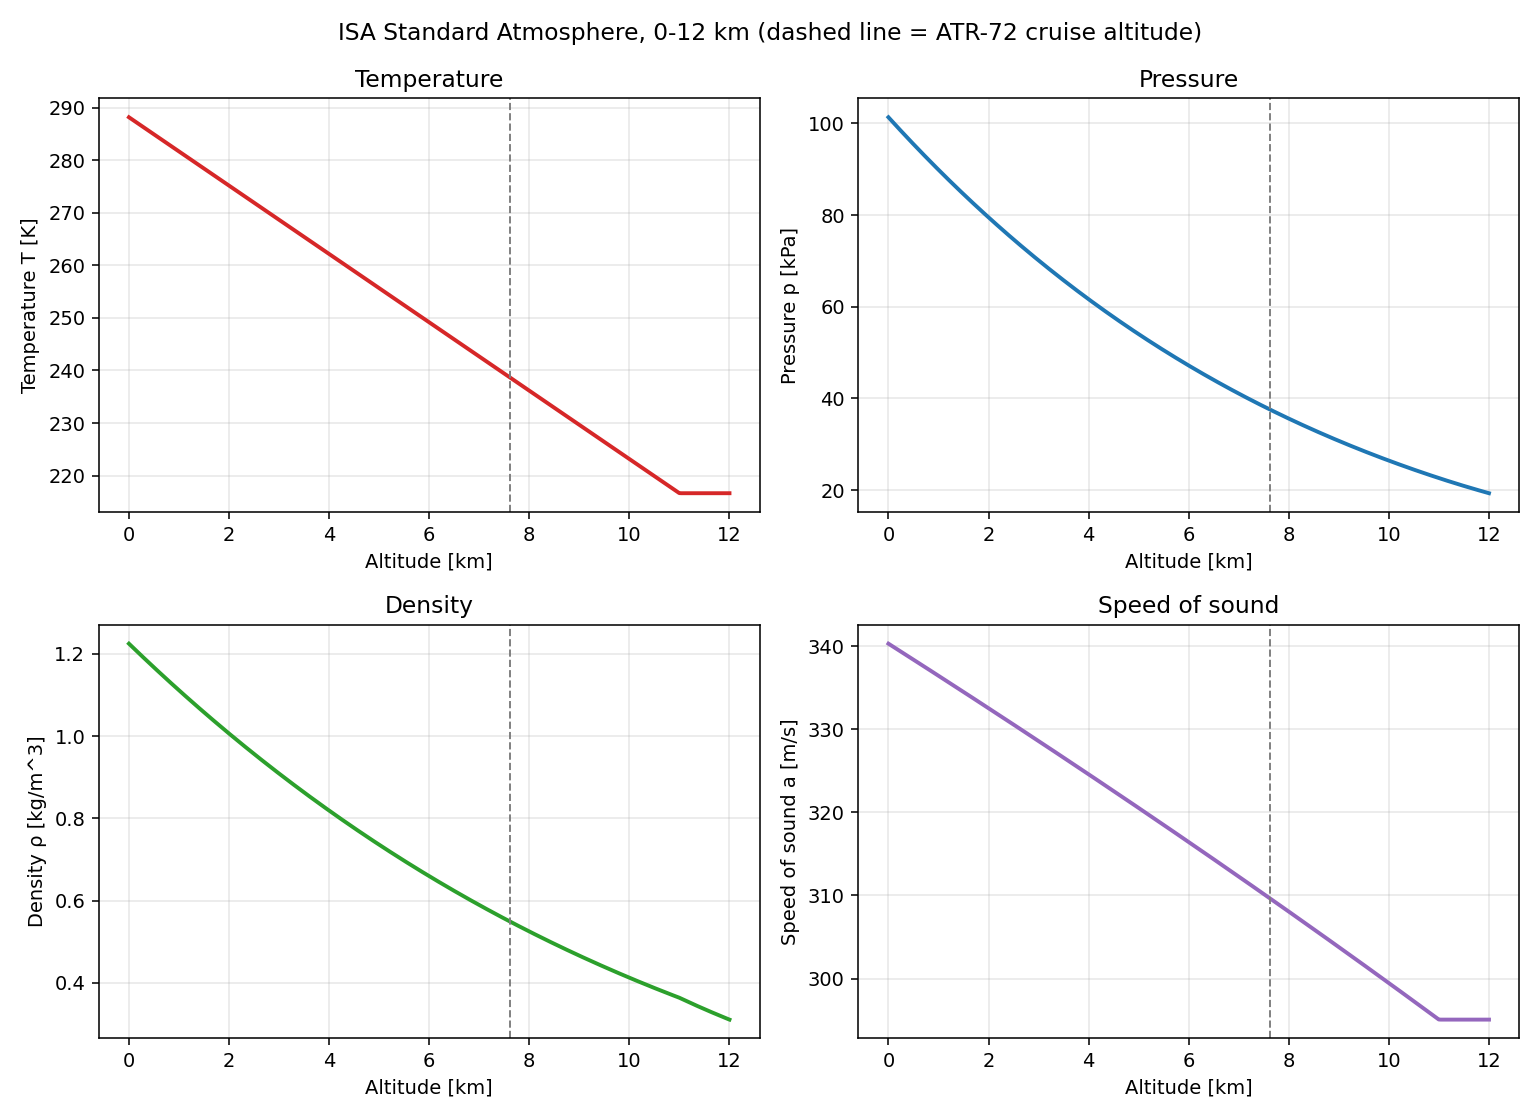

In [ ]:
h_plot = np.linspace(0, 12000, 300)
T_plot = isa_temperature(h_plot)
p_plot = isa_pressure(h_plot)
rho_plot = isa_density(h_plot)
a_plot = isa_speed_of_sound(h_plot)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
h_km = h_plot / 1000.0
cruise_km = Performance.cruise_altitude / 1000.0

panels = [
    (axes[0, 0], T_plot, "Temperature T [K]", "tab:red"),
    (axes[0, 1], p_plot / 1000.0, "Pressure p [kPa]", "tab:blue"),
    (axes[1, 0], rho_plot, "Density ρ [kg/m^3]", "tab:green"),
    (axes[1, 1], a_plot, "Speed of sound a [m/s]", "tab:purple"),
]
for ax, y, label, color in panels:
    ax.plot(h_km, y, color=color, lw=2)
    ax.axvline(cruise_km, color="gray", ls="--", lw=1, label="ATR-72 cruise alt.")
    ax.set_xlabel("Altitude [km]")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0, 0].set_title("Temperature")
axes[0, 1].set_title("Pressure")
axes[1, 0].set_title("Density")
axes[1, 1].set_title("Speed of sound")
axes[0, 0].legend(fontsize=8)
fig.suptitle("ISA Standard Atmosphere, 0-12 km", fontsize=13)
fig.tight_layout()
plt.show()

Interpretation: temperature and pressure fall off smoothly and
monotonically; density falls faster than pressure alone would suggest,
because temperature is also dropping — both effects work in the same
direction on `ρ = p/(RT)`... except that falling `T` alone would *raise* ρ
for fixed p, so it's really the pressure drop that dominates. Speed of
sound tracks the square root of temperature, which is why it flattens out
above the tropopause where `T` stops changing.

## 5. Reynolds number at cruise

The Reynolds number `Re = ρ V c / μ` characterizes the flow regime around
the wing (`c` = a representative chord length, `μ` = dynamic viscosity). It
is one of the two numbers (with Mach) that Phase 1 needs to configure the
Xfoil run correctly.

`μ` is estimated with **Sutherland's formula**, an empirical fit for how
air's viscosity increases with temperature.

Note: the chord `c` used here is `Geometry.mean_aerodynamic_chord_est` — the
crude `S/b` rectangular-wing approximation flagged in `atr72_specs.py`.
Phase 2.1 will replace it with the true tapered-wing MAC, and this Reynolds
number should be recomputed at that point.

In [ ]:
h_cruise = Performance.cruise_altitude
T_cruise = isa_temperature(h_cruise)
rho_cruise = isa_density(h_cruise)
a_cruise = isa_speed_of_sound(h_cruise)
mu_cruise = sutherland_viscosity(T_cruise)
V_cruise = Performance.max_cruise_speed_TAS
mach_cruise = V_cruise / a_cruise
mac = Geometry.mean_aerodynamic_chord_est

Re_cruise = rho_cruise * V_cruise * mac / mu_cruise

print(f"--- Cruise conditions at h = {h_cruise:.0f} m ---")
print(f"T    = {T_cruise:.2f} K")
print(f"rho  = {rho_cruise:.4f} kg/m^3")
print(f"a    = {a_cruise:.2f} m/s")
print(f"mu   = {mu_cruise:.4e} Pa.s")
print(f"V    = {V_cruise:.1f} m/s (TAS)")
print(f"Mach = {mach_cruise:.3f}")
print(f"MAC  = {mac:.3f} m (Phase 0 rectangular estimate)")
print(f"Re   = {Re_cruise:.3e}")

--- Cruise conditions at h = 7620 m ---
T    = 238.62 K
rho  = 0.5489 kg/m^3
a    = 309.67 m/s
mu   = 1.5397e-05 Pa.s
V    = 141.4 m/s (TAS)
Mach = 0.457
MAC  = 2.255 m (Phase 0 rectangular estimate)
Re   = 1.137e+07


**Result: Mach ≈ 0.457, Re ≈ 1.14 × 10⁷ at cruise.**

The Mach number matches the ~0.45 figure stated in the project plan for the
ATR-72's cruise regime, which is a useful independent cross-check. The
Reynolds number of order 10⁷ is typical for a transport-aircraft wing
section at cruise — Xfoil handles this range comfortably.

## Next step

Phase 1 (Airfoil Aerodynamics) uses `isa_temperature`, `isa_density`,
`isa_speed_of_sound`, and this Reynolds number to configure the Xfoil polar
sweep for the NACA 6-series airfoil standing in for the ATR-72's
proprietary profile.